In [3]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

import seaborn as sns

2026-06-27 20:30:03.465300: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-27 20:30:03.496394: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [39]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [40]:
meta_df_2 = meta_df.copy()
meta_df_2

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [41]:
meta_df_2['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [42]:
meta_df_2["condition_cat"] = meta_df_2["condition"].astype("category")
meta_df_2["condition_cat"] = meta_df_2["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df_2["condition_num"] = meta_df_2["condition_cat"].cat.codes


meta_df_2["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [43]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled'],
      dtype='object')

In [44]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [45]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled'

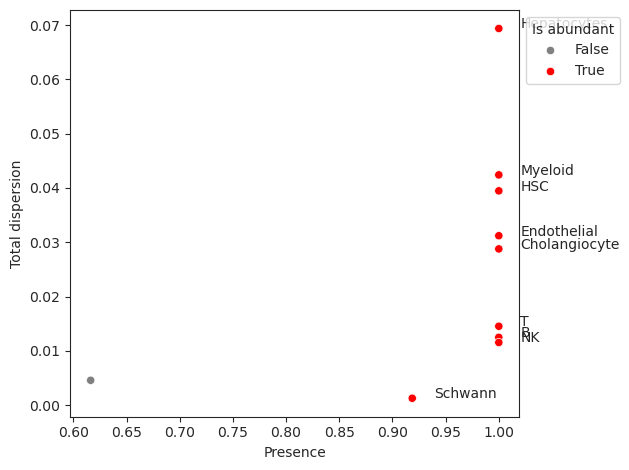

In [46]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

<Axes: xlabel='Cell type', ylabel='Proportion'>

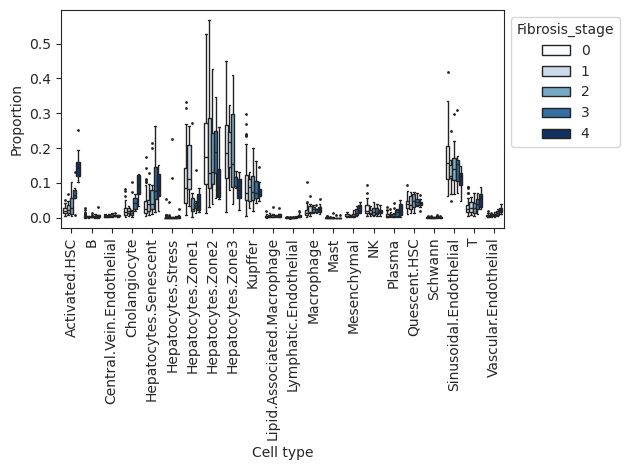

In [130]:
viz.boxplots(data_all, 'Fibrosis_stage', y_scale='relative')

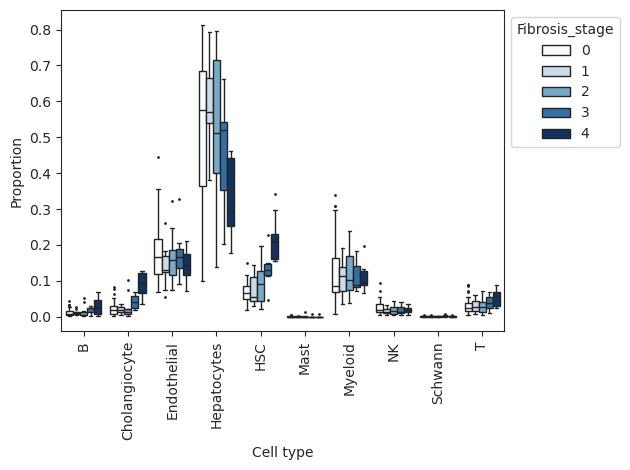

In [15]:
az = viz.boxplots(data_all, 'Fibrosis_stage', y_scale='relative')

In [16]:
model_all = mod.CompositionalAnalysis(data_all, formula="Fibrosis_stage", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


  0%|          | 0/20000 [00:00<?, ?it/s]WARNING: All log messages before absl::InitializeLog() is called are written to STDERR
I0000 00:00:1780000396.525230  329379 service.cc:148] XLA service 0x1554b8007240 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1780000396.525331  329379 service.cc:156]   StreamExecutor device (0): Host, Default Version
2026-05-28 13:33:17.563527: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1780000399.216080  329379 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [01:16<00:00, 260.68it/s]


MCMC sampling finished. (97.878 sec)
Acceptance rate: 55.6%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: Fibrosis_stage

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.272       105.070428
Cholangiocyte           -0.095       125.415330
Endothelial              1.768       808.055604
Hepatocytes              2.875      2444.585535
HSC                      0.884       333.829663
Mast                    -1.460        32.028652
Myeloid                  1.362       538.415664
NK                       0.043       143.973733
Schwann                 -1.243        39.790607
T                        0.240       175.323155


Effects:
                              Final Parameter  Expected Sample  \
Covariate      Cell Type                                         
Fibrosis_stage B                     0.000000       105.953457   
               Cholangiocyte      

In [17]:
all_results.set_fdr(est_fdr=0.05)
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: Fibrosis_stage

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.272       105.070428
Cholangiocyte           -0.095       125.415330
Endothelial              1.768       808.055604
Hepatocytes              2.875      2444.585535
HSC                      0.884       333.829663
Mast                    -1.460        32.028652
Myeloid                  1.362       538.415664
NK                       0.043       143.973733
Schwann                 -1.243        39.790607
T                        0.240       175.323155


Effects:
                              Final Parameter  Expected Sample  \
Covariate      Cell Type                                         
Fibrosis_stage B                     0.000000       102.194226   
               Cholangiocyte         0.252920       157.086340   
               Endothelial  

In [18]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results')

In [3]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [19]:
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: Fibrosis_stage

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.272       105.070428
Cholangiocyte           -0.095       125.415330
Endothelial              1.768       808.055604
Hepatocytes              2.875      2444.585535
HSC                      0.884       333.829663
Mast                    -1.460        32.028652
Myeloid                  1.362       538.415664
NK                       0.043       143.973733
Schwann                 -1.243        39.790607
T                        0.240       175.323155


Effects:
                              Final Parameter  Expected Sample  \
Covariate      Cell Type                                         
Fibrosis_stage B                     0.000000       105.953457   
               Cholangiocyte         0.252920       162.864787   
               Endothelial  

In [20]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(               Final Parameter  HDI 3%  HDI 97%     SD  Expected Sample
 Cell Type                                                              
 B                       -0.272  -0.442   -0.085  0.096       105.070428
 Cholangiocyte           -0.095  -0.322    0.128  0.121       125.415330
 Endothelial              1.768   1.635    1.905  0.073       808.055604
 Hepatocytes              2.875   2.735    3.016  0.076      2444.585535
 HSC                      0.884   0.702    1.066  0.096       333.829663
 Mast                    -1.460  -1.663   -1.227  0.117        32.028652
 Myeloid                  1.362   1.202    1.513  0.082       538.415664
 NK                       0.043  -0.143    0.219  0.099       143.973733
 Schwann                 -1.243  -1.446   -1.033  0.112        39.790607
 T                        0.240   0.018    0.444  0.117       175.323155,
                               Final Parameter  HDI 3%  HDI 97%     SD  \
 Covariate      Cell Type                        

## All Subtypes

In [66]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [67]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [68]:
(meta_df['donor_demux'] == meta_counts['donor']).sum()

np.int64(86)

In [69]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [70]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [71]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [72]:
combined_df_filt = combined_df.loc[:, ~combined_df.columns.duplicated(keep='last')]
combined_df_filt = combined_df_filt.drop(columns=['Endothelial', 'Hepatocytes','HSC', 'Myeloid'])
combined_df_filt.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'Activated.HSC', 'B',
       'Central.Vein.Endothelial', 'Cholangiocyte', 'Hepatocytes.Senescent',
       'Hepatocytes.Stress', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2',
       'Hepatocytes.Zone3', 'Kupffer', 'Lipid.Associated.Macrophage',
       'Lymphatic.Endothelial', 'Macrophage', 'Mast', 'Mesenchymal', 'NK',
       'Plasma', 'Quescent.HSC', 'Schwann', 'Sinusoidal.Endothelial', 'T',
       'Vascular.Endothelial'],
      dtype='object')

In [73]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df_filt.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df_filt.columns if c not in covariate_data.columns]
count_data = combined_df_filt.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [29]:
data_all

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled'

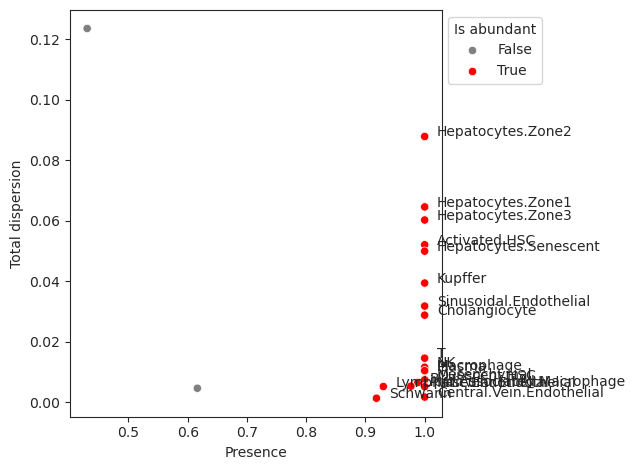

In [30]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

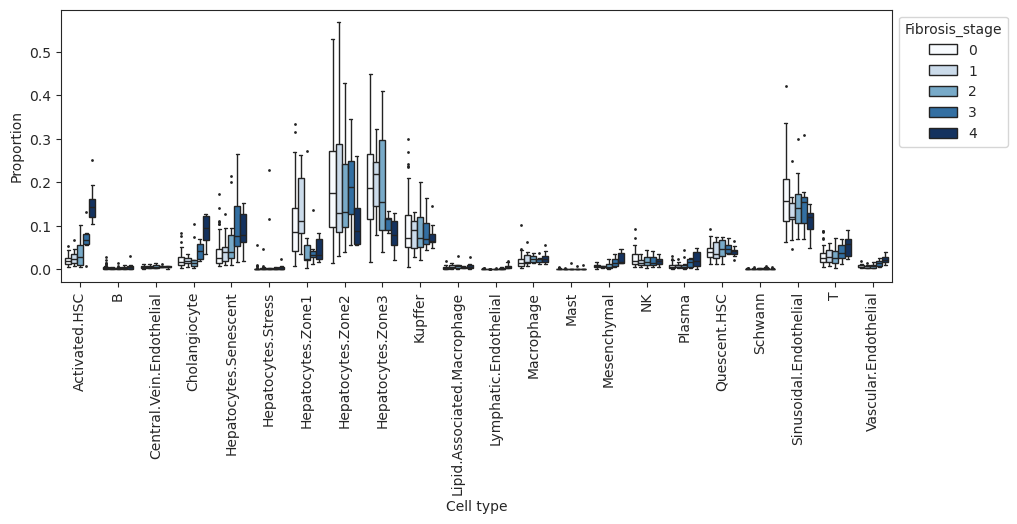

In [36]:
viz.boxplots(data_all, 'Fibrosis_stage', y_scale='relative')
plt.gcf().set_size_inches(12, 6)

In [29]:
model_all = mod.CompositionalAnalysis(data_all, formula="Fibrosis_stage", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


I0000 00:00:1779319179.591119 1231414 service.cc:148] XLA service 0x1554b4007230 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779319179.591174 1231414 service.cc:156]   StreamExecutor device (0): Host, Default Version
  0%|          | 0/20000 [00:00<?, ?it/s]2026-05-20 16:19:40.382964: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779319182.372514 1231414 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [03:51<00:00, 86.30it/s] 


MCMC sampling finished. (295.505 sec)
Acceptance rate: 38.9%
Compositional Analysis summary:

Data: 86 samples, 22 cell types
Reference index: 1
Formula: Fibrosis_stage

Intercepts:
                             Final Parameter  Expected Sample
Cell Type                                                    
Activated.HSC                          0.059       118.770139
B                                     -0.775        51.582890
Central.Vein.Endothelial              -0.534        65.640312
Cholangiocyte                          0.000       111.965414
Hepatocytes.Senescent                  0.515       187.389628
Hepatocytes.Stress                    -1.445        26.395407
Hepatocytes.Zone1                      1.267       397.498047
Hepatocytes.Zone2                      1.929       770.615867
Hepatocytes.Zone3                      2.017       841.503373
Kupffer                                1.326       421.656087
Lipid.Associated.Macrophage           -0.769        51.893317
Lymphatic.En

In [31]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_cell_subtype.results')

In [32]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(                             Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                              
 Activated.HSC                          0.059  -0.184    0.205  0.100   
 B                                     -0.775  -0.943   -0.608  0.083   
 Central.Vein.Endothelial              -0.534  -0.739   -0.397  0.097   
 Cholangiocyte                          0.000  -0.173    0.202  0.093   
 Hepatocytes.Senescent                  0.515   0.307    0.648  0.096   
 Hepatocytes.Stress                    -1.445  -1.695   -1.250  0.111   
 Hepatocytes.Zone1                      1.267   1.109    1.389  0.071   
 Hepatocytes.Zone2                      1.929   1.804    2.009  0.059   
 Hepatocytes.Zone3                      2.017   1.907    2.128  0.055   
 Kupffer                                1.326   1.202    1.436  0.061   
 Lipid.Associated.Macrophage           -0.769  -0.967   -0.563  0.111   
 Lymphatic.Endothelial                 -1.292  -1.5

## Hepatocytes

In [56]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [57]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [58]:
(meta_df['donor_demux'] == meta_counts['donor']).sum()

np.int64(86)

In [59]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [60]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [61]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [62]:
combined_df = combined_df.drop(columns=['B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'])
combined_df.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'Hepatocytes.Senescent',
       'Hepatocytes.Stress', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2',
       'Hepatocytes.Zone3'],
      dtype='object')

In [63]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df.columns if c not in covariate_data.columns]
count_data = combined_df.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [64]:
data_all

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled'

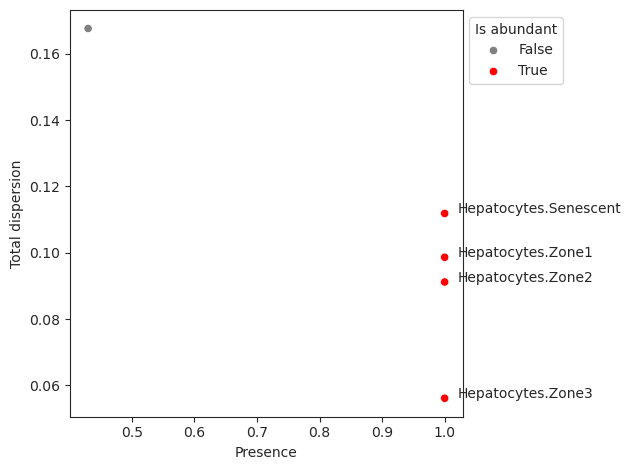

In [44]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

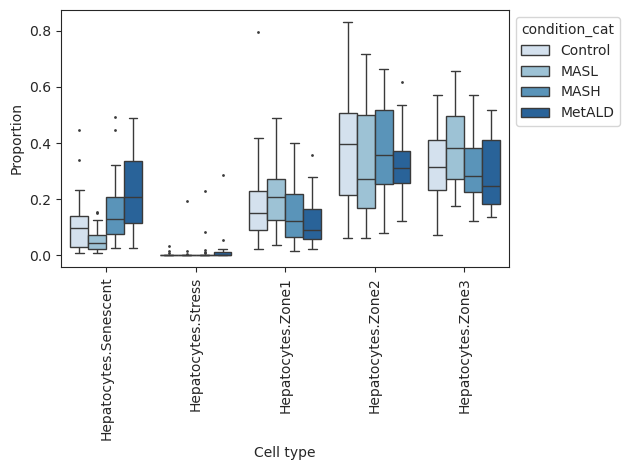

In [68]:
az = viz.boxplots(data_all, 'Fibrosis_stage', y_scale='relative')

In [45]:
model_all = mod.CompositionalAnalysis(data_all, formula="Fibrosis_stage", reference_cell_type="Hepatocytes.Zone2")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [02:07<00:00, 157.27it/s]


MCMC sampling finished. (160.689 sec)
Acceptance rate: 11.2%
Compositional Analysis summary:

Data: 86 samples, 5 cell types
Reference index: 3
Formula: Fibrosis_stage

Intercepts:
                       Final Parameter  Expected Sample
Cell Type                                              
Hepatocytes.Senescent           -3.697         8.248147
Hepatocytes.Stress              -1.652        63.751239
Hepatocytes.Zone1                0.385       488.817211
Hepatocytes.Zone2                1.151      1051.516428
Hepatocytes.Zone3                1.200      1104.323952


Effects:
                                      Final Parameter  Expected Sample  \
Covariate      Cell Type                                                 
Fibrosis_stage Hepatocytes.Senescent       114.865732     2.716657e+03   
               Hepatocytes.Stress            0.000000     2.732836e-46   
               Hepatocytes.Zone1             0.000000     2.095421e-45   
               Hepatocytes.Zone2             0

In [46]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results')

In [2]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results', "rb") as f:
#    all_results = pkl.load(f)

In [3]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(                       Final Parameter  HDI 3%  HDI 97%   SD  Expected Sample
 Cell Type                                                                    
 Hepatocytes.Senescent           -3.697  -3.697   -3.697  0.0         8.248147
 Hepatocytes.Stress              -1.652  -1.652   -1.652  0.0        63.751239
 Hepatocytes.Zone1                0.385   0.385    0.385  0.0       488.817211
 Hepatocytes.Zone2                1.151   1.151    1.151  0.0      1051.516428
 Hepatocytes.Zone3                1.200   1.200    1.200  0.0      1104.323952,
                                       Final Parameter   HDI 3%  HDI 97%   SD  \
 Covariate      Cell Type                                                       
 Fibrosis_stage Hepatocytes.Senescent       114.865732  114.866  114.866  0.0   
                Hepatocytes.Stress            0.000000      NaN      NaN  0.0   
                Hepatocytes.Zone1             0.000000      NaN      NaN  0.0   
                Hepatocytes.Zone2        

# Repeat for disease

In [1]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

2026-05-29 11:14:36.000110: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-29 11:14:36.031557: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [3]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [4]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df["condition_num"] = meta_df["condition_cat"].cat.codes


meta_df["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [5]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num'],
      dtype='object')

In [6]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [7]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat','condition_num'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

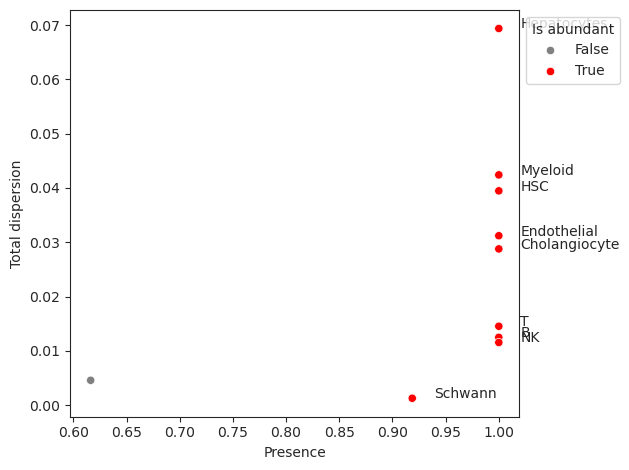

In [8]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

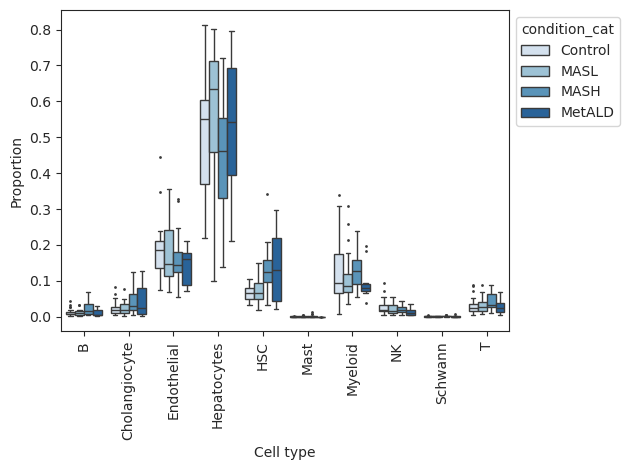

In [98]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [100]:
data_ct = data_all

In [25]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


I0000 00:00:1779914249.757160  192073 service.cc:148] XLA service 0x1554c0007250 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779914249.757271  192073 service.cc:156]   StreamExecutor device (0): Host, Default Version
  0%|          | 0/20000 [00:00<?, ?it/s]2026-05-27 13:37:30.427412: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1779914251.319283  192073 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [01:17<00:00, 259.13it/s]


MCMC sampling finished. (98.971 sec)
Acceptance rate: 3.6%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.408       113.014994
Cholangiocyte           -0.600        93.272051
Endothelial              1.681       912.803382
Hepatocytes              2.630      2357.885457
HSC                    -10.419         0.005075
Mast                    -1.344        44.323743
Myeloid                  1.538       791.176045
NK                      -0.762        79.322395
Schwann                 -1.095        56.855929
T                        0.561       297.829300


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     0.000000     1.459022e-53   
              Cholangiocyte       130.3

In [26]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_num.results')

In [3]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [27]:
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.408       113.014994
Cholangiocyte           -0.600        93.272051
Endothelial              1.681       912.803382
Hepatocytes              2.630      2357.885457
HSC                    -10.419         0.005075
Mast                    -1.344        44.323743
Myeloid                  1.538       791.176045
NK                      -0.762        79.322395
Schwann                 -1.095        56.855929
T                        0.561       297.829300


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     0.000000     1.459022e-53   
              Cholangiocyte       130.316404     4.746488e+03   
              Endothelial        

In [28]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(               Final Parameter  HDI 3%  HDI 97%   SD  Expected Sample
 Cell Type                                                            
 B                       -0.408  -0.408   -0.408  0.0       113.014994
 Cholangiocyte           -0.600  -0.600   -0.600  0.0        93.272051
 Endothelial              1.681   1.681    1.681  0.0       912.803382
 Hepatocytes              2.630   2.630    2.630  0.0      2357.885457
 HSC                    -10.419 -10.419  -10.419  0.0         0.005075
 Mast                    -1.344  -1.344   -1.344  0.0        44.323743
 Myeloid                  1.538   1.538    1.538  0.0       791.176045
 NK                      -0.762  -0.762   -0.762  0.0        79.322395
 Schwann                 -1.095  -1.095   -1.095  0.0        56.855929
 T                        0.561   0.561    0.561  0.0       297.829300,
                              Final Parameter   HDI 3%  HDI 97%   SD  \
 Covariate     Cell Type                                               
 co

## All Subtypes

In [101]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [102]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [103]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df["condition_num"] = meta_df["condition_cat"].cat.codes


meta_df["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [104]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num'],
      dtype='object')

In [105]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [106]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [107]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [108]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num', 'Activated.HSC', 'B', 'Central.Vein.Endothelial',
       'Cholangiocyte', 'Hepatocytes.Senescent', 'Hepatocytes.Stress',
       'Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3',
       'Kupffer', 'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial',
       'Macrophage', 'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC',
       'Schwann', 'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [109]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [110]:
combined_df_filt = combined_df.loc[:, ~combined_df.columns.duplicated(keep='last')]
combined_df_filt = combined_df_filt.drop(columns=['Endothelial', 'Hepatocytes','HSC', 'Myeloid'])
combined_df_filt.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num',
       'Activated.HSC', 'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [111]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df_filt.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat','condition_num']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df_filt.columns if c not in covariate_data.columns]
count_data = combined_df_filt.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [112]:
data_all

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [113]:
data_sub=data_all

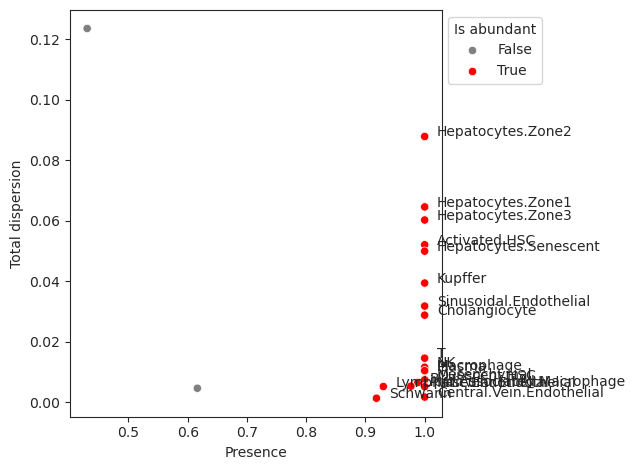

In [42]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

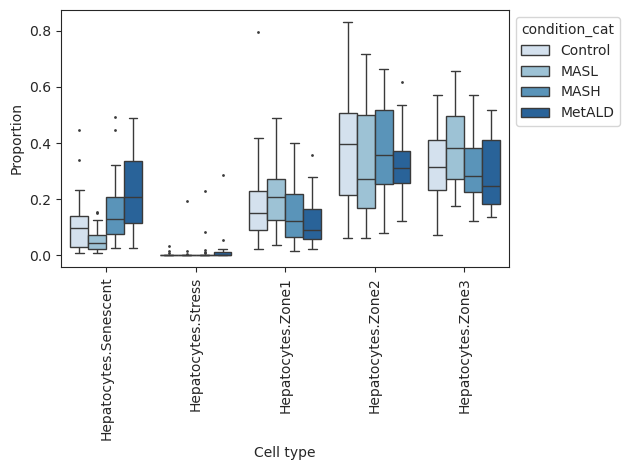

In [68]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [43]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:38<00:00, 202.80it/s]


MCMC sampling finished. (124.897 sec)
Acceptance rate: 45.3%
Compositional Analysis summary:

Data: 86 samples, 22 cell types
Reference index: 1
Formula: condition_num

Intercepts:
                             Final Parameter  Expected Sample
Cell Type                                                    
Activated.HSC                          0.169       138.678020
B                                     -0.814        51.891492
Central.Vein.Endothelial              -0.617        63.190555
Cholangiocyte                          0.174       139.373146
Hepatocytes.Senescent                  0.429       179.855696
Hepatocytes.Stress                    -1.474        26.820187
Hepatocytes.Zone1                      1.138       365.459272
Hepatocytes.Zone2                      1.862       753.820927
Hepatocytes.Zone3                      1.888       773.677285
Kupffer                                1.289       425.027912
Lipid.Associated.Macrophage           -0.816        51.787813
Lymphatic.End

In [44]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype.results')

In [45]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(                             Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                              
 Activated.HSC                          0.169  -0.057    0.385  0.120   
 B                                     -0.814  -1.009   -0.640  0.097   
 Central.Vein.Endothelial              -0.617  -0.803   -0.405  0.108   
 Cholangiocyte                          0.174  -0.072    0.380  0.131   
 Hepatocytes.Senescent                  0.429   0.191    0.671  0.131   
 Hepatocytes.Stress                    -1.474  -1.742   -1.218  0.140   
 Hepatocytes.Zone1                      1.138   0.938    1.330  0.104   
 Hepatocytes.Zone2                      1.862   1.711    2.003  0.079   
 Hepatocytes.Zone3                      1.888   1.729    2.042  0.095   
 Kupffer                                1.289   1.155    1.521  0.105   
 Lipid.Associated.Macrophage           -0.816  -1.060   -0.570  0.138   
 Lymphatic.Endothelial                 -1.290  -1.5

## Hepatocytes

In [77]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [78]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [79]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df["condition_num"] = meta_df["condition_cat"].cat.codes


meta_df["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [80]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num'],
      dtype='object')

In [81]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [82]:
(meta_df['donor_demux'] == meta_counts['donor']).sum()

np.int64(86)

In [83]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [84]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num', 'Activated.HSC', 'B', 'Central.Vein.Endothelial',
       'Cholangiocyte', 'Hepatocytes.Senescent', 'Hepatocytes.Stress',
       'Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3',
       'Kupffer', 'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial',
       'Macrophage', 'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC',
       'Schwann', 'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [85]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [86]:
combined_df = combined_df.drop(columns=['B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'])
combined_df.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3'],
      dtype='object')

In [87]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat','condition_num']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df.columns if c not in covariate_data.columns]
count_data = combined_df.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [88]:
data_all

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [89]:
data_hep = data_all

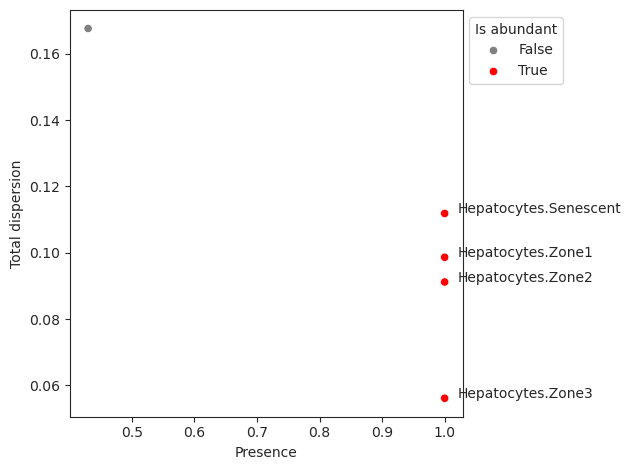

In [58]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

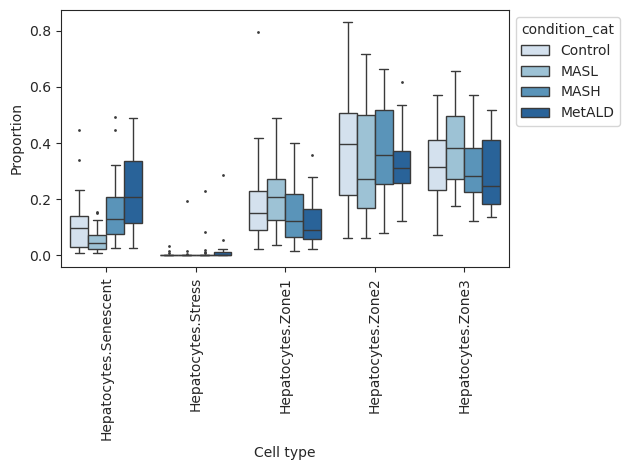

In [68]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [59]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="Hepatocytes.Zone2")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:08<00:00, 290.76it/s]


MCMC sampling finished. (85.751 sec)
Acceptance rate: 8.3%
Compositional Analysis summary:

Data: 86 samples, 5 cell types
Reference index: 3
Formula: condition_num

Intercepts:
                       Final Parameter  Expected Sample
Cell Type                                              
Hepatocytes.Senescent           -1.488        82.805483
Hepatocytes.Stress              -1.427        88.013858
Hepatocytes.Zone1               -3.508        10.984600
Hepatocytes.Zone2                1.289      1330.745087
Hepatocytes.Zone3                1.189      1204.107949


Effects:
                                     Final Parameter  Expected Sample  \
Covariate     Cell Type                                                 
condition_num Hepatocytes.Senescent        -6.605166     8.855923e-31   
              Hepatocytes.Stress            0.000000     6.955252e-28   
              Hepatocytes.Zone1            72.521043     2.716657e+03   
              Hepatocytes.Zone2             0.000000  

In [60]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype.results')

In [2]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results', "rb") as f:
#    all_results = pkl.load(f)

In [61]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(                       Final Parameter  HDI 3%  HDI 97%   SD  Expected Sample
 Cell Type                                                                    
 Hepatocytes.Senescent           -1.488  -1.488   -1.488  0.0        82.805483
 Hepatocytes.Stress              -1.427  -1.427   -1.427  0.0        88.013858
 Hepatocytes.Zone1               -3.508  -3.508   -3.508  0.0        10.984600
 Hepatocytes.Zone2                1.289   1.289    1.289  0.0      1330.745087
 Hepatocytes.Zone3                1.189   1.189    1.189  0.0      1204.107949,
                                      Final Parameter  HDI 3%  HDI 97%   SD  \
 Covariate     Cell Type                                                      
 condition_num Hepatocytes.Senescent        -6.605166  -6.605   -6.605  0.0   
               Hepatocytes.Stress            0.000000     NaN      NaN  0.0   
               Hepatocytes.Zone1            72.521043  72.521   72.521  0.0   
               Hepatocytes.Zone2             0.0000

In [114]:
data_hep

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [115]:
data_ct

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [116]:
data_sub

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [152]:
viz.boxplots(data_ct, 'Fibrosis_stage', y_scale='relative')
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Celltypes_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [158]:
viz.boxplots(data_sub, 'Fibrosis_stage', y_scale='relative')
plt.gcf().set_size_inches(12, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Subtypes_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [154]:
viz.boxplots(data_hep, 'Fibrosis_stage', y_scale='relative')
plt.gcf().set_size_inches(3, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Hep_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [155]:
viz.boxplots(data_ct, 'condition_cat', y_scale='relative')
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Celltypes_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [156]:
viz.boxplots(data_sub, 'condition_cat', y_scale='relative')
plt.gcf().set_size_inches(12, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Subtypes_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [157]:
viz.boxplots(data_hep, 'condition_cat', y_scale='relative')
plt.gcf().set_size_inches(3, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Hep_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [166]:
sns.color_palette(palette='Oranges')

[(0.9955709342560554, 0.8907958477508651, 0.7855132641291811),
 (0.9921568627450981, 0.7769934640522875, 0.5727028066128412),
 (0.9921568627450981, 0.6280507497116494, 0.34226835832372166),
 (0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

In [9]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

In [10]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [11]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [12]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df["condition_num"] = meta_df["condition_cat"].cat.codes


meta_df["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [13]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num'],
      dtype='object')

In [14]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [15]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat','condition_num'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

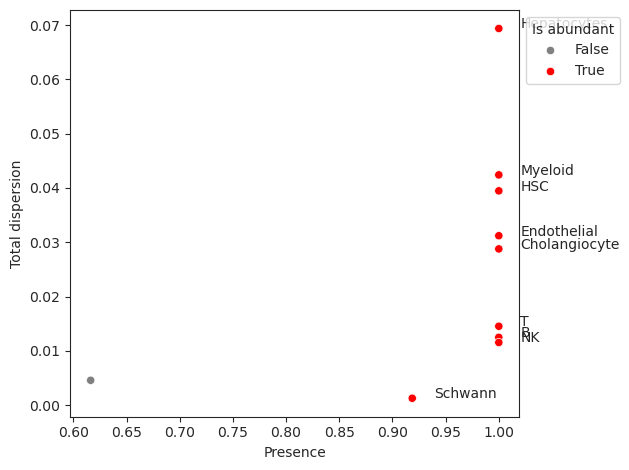

In [16]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

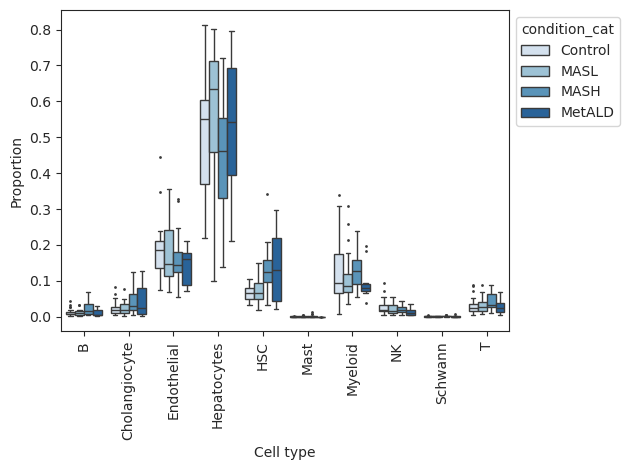

In [17]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [18]:
data_ct = data_all

In [29]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="Endothelial")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:14<00:00, 269.80it/s]


MCMC sampling finished. (94.334 sec)
Acceptance rate: 19.3%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 2
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.516        99.864470
Cholangiocyte           -0.667        85.868235
Endothelial              1.625       849.641051
Hepatocytes              2.807      2770.585553
HSC                     -2.163        19.236586
Mast                    -1.363        42.811809
Myeloid                  1.109       507.153626
NK                      -0.047       159.622870
Schwann                 -2.880         9.391584
T                        0.190       202.312588


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     1.911651     1.786306e-19   
              Cholangiocyte        -3.

In [30]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:13<00:00, 273.12it/s]


MCMC sampling finished. (92.549 sec)
Acceptance rate: 58.0%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.333       106.104754
Cholangiocyte            0.011       149.669099
Endothelial              1.722       828.342609
Hepatocytes              2.756      2329.541738
HSC                      0.941       379.337704
Mast                    -1.481        33.663927
Myeloid                  1.293       539.383515
NK                       0.008       149.220764
Schwann                 -1.253        42.284765
T                        0.244       188.939498


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                          0.0       106.104754   
              Cholangiocyte           

In [25]:
all_results.set_fdr(est_fdr=0.1)
#all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_num.results')

In [26]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [27]:
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 9
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.212       120.030821
Cholangiocyte           -0.042       142.273115
Endothelial             -3.115         6.584699
Hepatocytes              3.035      3086.362687
HSC                      0.998       402.521517
Mast                    -1.343        38.735192
Myeloid                  1.389       595.111363
NK                      -0.087       136.012739
Schwann                 -2.157        17.162874
T                        0.307       201.693366


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     0.000000     6.381741e-55   
              Cholangiocyte        -1.844803     1.195588e-55   
              Endothelial        

In [31]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(               Final Parameter  HDI 3%  HDI 97%     SD  Expected Sample
 Cell Type                                                              
 B                       -0.333  -0.531   -0.154  0.106       106.104754
 Cholangiocyte            0.011  -0.243    0.232  0.129       149.669099
 Endothelial              1.722   1.540    1.907  0.102       828.342609
 Hepatocytes              2.756   2.609    2.920  0.085      2329.541738
 HSC                      0.941   0.705    1.156  0.124       379.337704
 Mast                    -1.481  -1.699   -1.250  0.118        33.663927
 Myeloid                  1.293   1.138    1.447  0.084       539.383515
 NK                       0.008  -0.211    0.227  0.115       149.220764
 Schwann                 -1.253  -1.474   -1.026  0.123        42.284765
 T                        0.244   0.069    0.433  0.098       188.939498,
                              Final Parameter  HDI 3%  HDI 97%     SD  \
 Covariate     Cell Type                          

# Non ordinal disease

# Repeat for disease

In [1]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

2026-06-26 21:52:06.335467: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-26 21:52:07.753802: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX512F AVX512_VNNI, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [3]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [4]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "MASH", "MetALD"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'MASH', 'MetALD']

In [5]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'],
      dtype='object')

In [6]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [9]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'

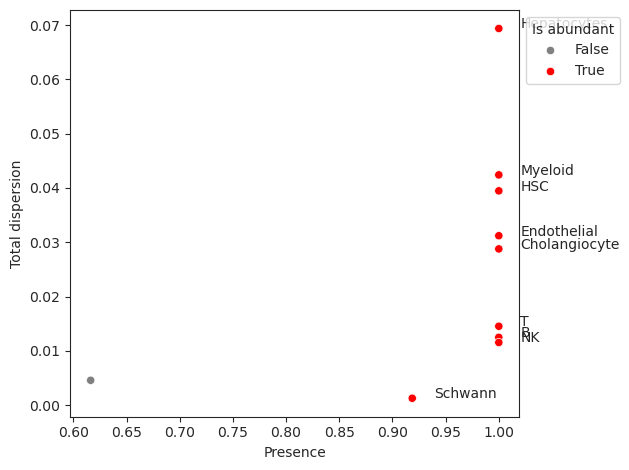

In [10]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

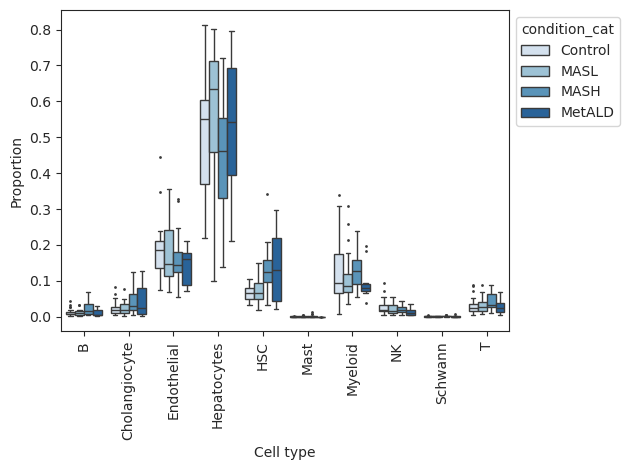

In [11]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [12]:
data_ct = data_all

In [13]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


I0000 00:00:1782536108.590137 3254735 service.cc:148] XLA service 0x1554cc007240 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782536108.590248 3254735 service.cc:156]   StreamExecutor device (0): Host, Default Version
2026-06-26 21:55:09.045805: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782536109.977082 3254735 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [01:19<00:00, 251.36it/s]


MCMC sampling finished. (103.566 sec)
Acceptance rate: 49.9%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.315       106.269532
Cholangiocyte            0.056       154.004007
Endothelial              1.710       805.109764
Hepatocytes              2.784      2356.608107
HSC                      0.989       391.497301
Mast                    -1.491        32.785247
Myeloid                  1.294       531.115027
NK                      -0.006       144.745731
Schwann                 -1.261        41.263512
T                        0.229       183.090144


Effects:
                                                                Final Parameter  \
Covariate                                        Cell Type                        
C(condition_cat, Treatment('Control'))[T.

In [14]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_distinct.results')

In [3]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [15]:
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.315       106.269532
Cholangiocyte            0.056       154.004007
Endothelial              1.710       805.109764
Hepatocytes              2.784      2356.608107
HSC                      0.989       391.497301
Mast                    -1.491        32.785247
Myeloid                  1.294       531.115027
NK                      -0.006       144.745731
Schwann                 -1.261        41.263512
T                        0.229       183.090144


Effects:
                                                                Final Parameter  \
Covariate                                        Cell Type                        
C(condition_cat, Treatment('Control'))[T.MASL]   B                     0.000000   
                   

In [16]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(               Final Parameter  HDI 3%  HDI 97%     SD  Expected Sample
 Cell Type                                                              
 B                       -0.315  -0.491   -0.127  0.097       106.269532
 Cholangiocyte            0.056  -0.142    0.246  0.104       154.004007
 Endothelial              1.710   1.559    1.860  0.080       805.109764
 Hepatocytes              2.784   2.639    2.929  0.078      2356.608107
 HSC                      0.989   0.828    1.193  0.099       391.497301
 Mast                    -1.491  -1.708   -1.263  0.119        32.785247
 Myeloid                  1.294   1.148    1.479  0.088       531.115027
 NK                      -0.006  -0.202    0.190  0.106       144.745731
 Schwann                 -1.261  -1.474   -1.042  0.119        41.263512
 T                        0.229   0.030    0.410  0.105       183.090144,
                                                                 Final Parameter  \
 Covariate                             

## All Subtypes

In [22]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [23]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [24]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "MASH", "MetALD"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'MASH', 'MetALD']

In [20]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'],
      dtype='object')

In [21]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [22]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [23]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [24]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'Activated.HSC', 'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [25]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [26]:
combined_df_filt = combined_df.loc[:, ~combined_df.columns.duplicated(keep='last')]
combined_df_filt = combined_df_filt.drop(columns=['Endothelial', 'Hepatocytes','HSC', 'Myeloid'])
combined_df_filt.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_cat', 'Activated.HSC', 'B',
       'Central.Vein.Endothelial', 'Cholangiocyte', 'Hepatocytes.Senescent',
       'Hepatocytes.Stress', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2',
       'Hepatocytes.Zone3', 'Kupffer', 'Lipid.Associated.Macrophage',
       'Lymphatic.Endothelial', 'Macrophage', 'Mast', 'Mesenchymal', 'NK',
       'Plasma', 'Quescent.HSC', 'Schwann', 'Sinusoidal.Endothelial', 'T',
       'Vascular.Endothelial'],
      dtype='object')

In [27]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df_filt.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df_filt.columns if c not in covariate_data.columns]
count_data = combined_df_filt.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [28]:
data_all

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'

In [29]:
data_sub=data_all

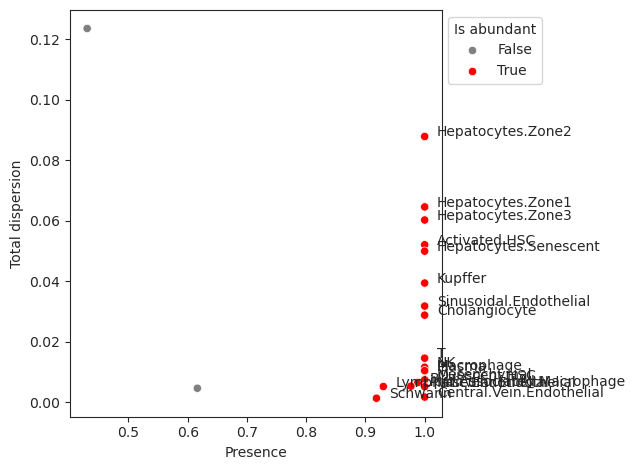

In [30]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

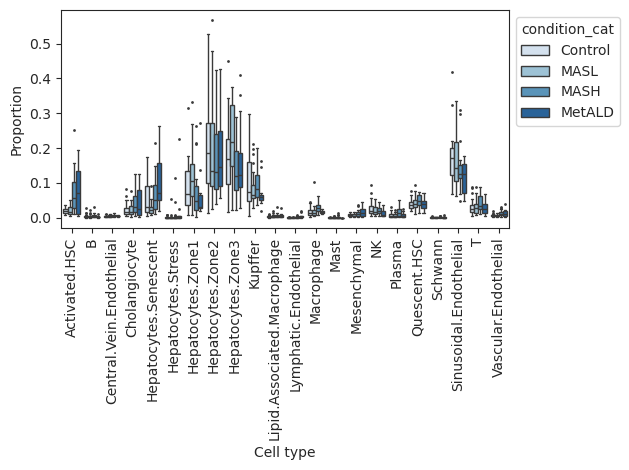

In [31]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [32]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [02:00<00:00, 165.94it/s]


MCMC sampling finished. (153.215 sec)
Acceptance rate: 68.5%
Compositional Analysis summary:

Data: 86 samples, 22 cell types
Reference index: 1
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
                             Final Parameter  Expected Sample
Cell Type                                                    
Activated.HSC                          0.277       157.325018
B                                     -0.804        53.373472
Central.Vein.Endothelial              -0.601        65.386371
Cholangiocyte                          0.207       146.688874
Hepatocytes.Senescent                  0.673       233.764417
Hepatocytes.Stress                    -1.428        28.597344
Hepatocytes.Zone1                      1.031       334.391962
Hepatocytes.Zone2                      1.856       763.042586
Hepatocytes.Zone3                      1.785       710.745091
Kupffer                                1.278       428.081605
Lipid.Associated.Macrophage           -0.762      

In [33]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.results')

In [57]:
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.results', "rb") as f:
    all_results = pkl.load(f)

In [60]:
#all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare(est_fdr=0.1)

(                             Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                              
 Activated.HSC                          0.277   0.055    0.482  0.112   
 B                                     -0.804  -1.005   -0.619  0.102   
 Central.Vein.Endothelial              -0.601  -0.805   -0.402  0.108   
 Cholangiocyte                          0.207   0.006    0.397  0.104   
 Hepatocytes.Senescent                  0.673   0.444    0.898  0.123   
 Hepatocytes.Stress                    -1.428  -1.661   -1.205  0.123   
 Hepatocytes.Zone1                      1.031   0.837    1.250  0.111   
 Hepatocytes.Zone2                      1.856   1.732    1.977  0.065   
 Hepatocytes.Zone3                      1.785   1.638    1.952  0.084   
 Kupffer                                1.278   1.132    1.416  0.076   
 Lipid.Associated.Macrophage           -0.762  -0.977   -0.559  0.112   
 Lymphatic.Endothelial                 -1.232  -1.4

In [65]:
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.sccoda_effects.csv", sep='\t')

## Hepatocytes

In [4]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [5]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [6]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "MASH", "MetALD"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'MASH', 'MetALD']

In [7]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'],
      dtype='object')

In [8]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [9]:
(meta_df['donor_demux'] == meta_counts['donor']).sum()

np.int64(86)

In [10]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [11]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'Activated.HSC', 'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [12]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [13]:
combined_df = combined_df.drop(columns=['B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'])
combined_df.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_cat', 'Hepatocytes.Senescent',
       'Hepatocytes.Stress', 'Hepatocytes.Zone1', 'Hepatocytes.Zone2',
       'Hepatocytes.Zone3'],
      dtype='object')

In [14]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df.columns if c not in covariate_data.columns]
count_data = combined_df.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [15]:
data_all

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat'

In [16]:
data_hep = data_all

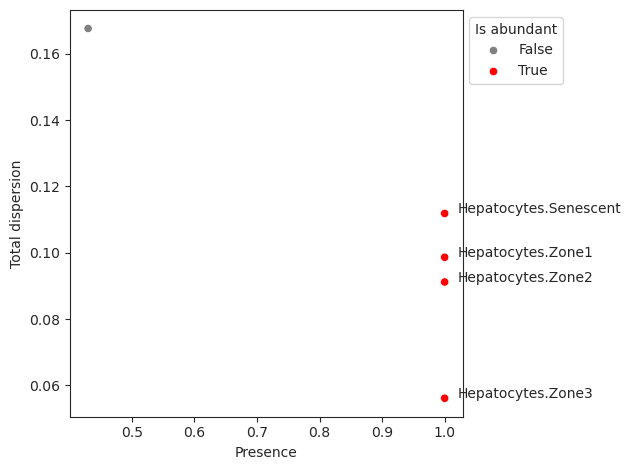

In [17]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

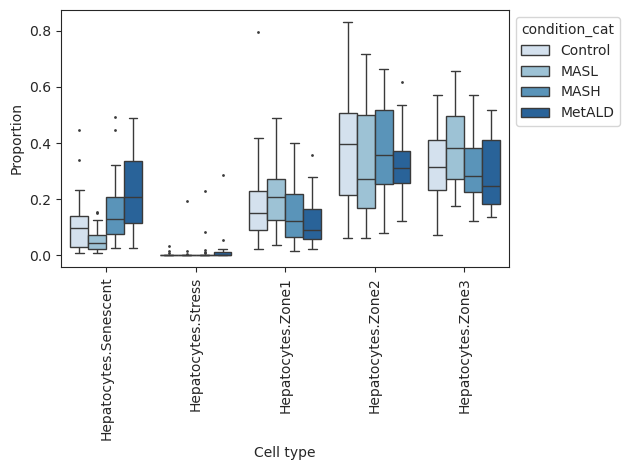

In [49]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [18]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="Hepatocytes.Zone2")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


I0000 00:00:1782617518.544704 3412647 service.cc:148] XLA service 0x1554d8007280 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782617518.544727 3412647 service.cc:156]   StreamExecutor device (0): Host, Default Version
2026-06-27 20:31:58.592866: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782617519.118053 3412647 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
100%|██████████| 20000/20000 [01:03<00:00, 313.79it/s]


MCMC sampling finished. (82.710 sec)
Acceptance rate: 60.9%
Compositional Analysis summary:

Data: 86 samples, 5 cell types
Reference index: 3
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
                       Final Parameter  Expected Sample
Cell Type                                              
Hepatocytes.Senescent            0.119       334.828285
Hepatocytes.Stress              -1.601        59.956411
Hepatocytes.Zone1                0.421       452.875756
Hepatocytes.Zone2                1.173       960.657378
Hepatocytes.Zone3                1.117       908.339147


Effects:
                                                                        Final Parameter  \
Covariate                                        Cell Type                                
C(condition_cat, Treatment('Control'))[T.MASL]   Hepatocytes.Senescent              0.0   
                                                 Hepatocytes.Stress                 0.0   
                             

In [19]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_distinct.results')

In [20]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results', "rb") as f:
#    all_results = pkl.load(f)

In [21]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare(est_fdr=0.1)

(                       Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                        
 Hepatocytes.Senescent            0.119  -0.172    0.413  0.158   
 Hepatocytes.Stress              -1.601  -1.827   -1.371  0.126   
 Hepatocytes.Zone1                0.421   0.191    0.651  0.123   
 Hepatocytes.Zone2                1.173   0.985    1.348  0.098   
 Hepatocytes.Zone3                1.117   0.891    1.320  0.113   
 
                        Expected Sample  
 Cell Type                               
 Hepatocytes.Senescent       334.828285  
 Hepatocytes.Stress           59.956411  
 Hepatocytes.Zone1           452.875756  
 Hepatocytes.Zone2           960.657378  
 Hepatocytes.Zone3           908.339147  ,
                                                                         Final Parameter  \
 Covariate                                        Cell Type                                
 C(condition_cat, Treatment('Control'))[T.MASL]   

# Low and High Fib pairwise

In [29]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

import numpy as np

In [26]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [31]:
meta_df["condition_fib"] = np.select(
    [
        meta_df["condition"] == "Control",
        meta_df["condition"] == "MASL",
        meta_df["Fibrosis.stage"] <= 2,
    ],
    [
        "Control",
        "MASL",
        "Low_Fib",
    ],
    default="High_Fib"
)

In [32]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [33]:
meta_df['condition_fib']

0        MASL
1        MASL
2     Low_Fib
3        MASL
4     Low_Fib
       ...   
81    Low_Fib
82    Low_Fib
83    Control
84       MASL
85    Low_Fib
Name: condition_fib, Length: 86, dtype: object

In [34]:
meta_df["condition_cat"] = meta_df["condition_fib"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "Low_Fib", "High_Fib"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2     Low_Fib
3        MASL
4     Low_Fib
       ...   
81    Low_Fib
82    Low_Fib
83    Control
84       MASL
85    Low_Fib
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'Low_Fib', 'High_Fib']

In [35]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib',
       'condition_cat'],
      dtype='object')

In [36]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [48]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat'

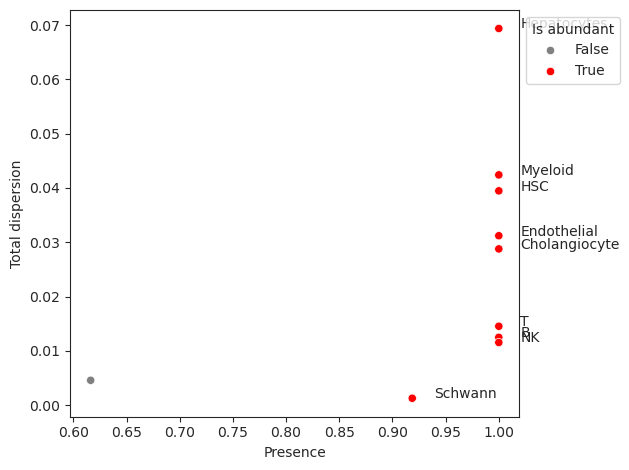

In [49]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

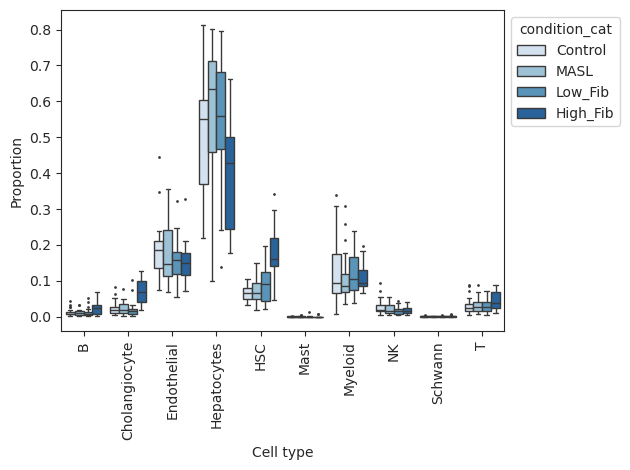

In [50]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [51]:
data_ct = data_all

In [52]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:18<00:00, 253.50it/s]


MCMC sampling finished. (100.993 sec)
Acceptance rate: 66.2%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.268       103.029716
Cholangiocyte            0.029       138.658968
Endothelial              1.780       798.725597
Hepatocytes              2.881      2401.905006
HSC                      1.015       371.674122
Mast                    -1.471        30.938998
Myeloid                  1.382       536.473654
NK                       0.055       142.311377
Schwann                 -1.241        38.939823
T                        0.311       183.831110


Effects:
                                                                  Final Parameter  \
Covariate                                          Cell Type                        
C(condition_cat, Treatment('Control')

In [53]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_by_fib_pairwise.results')

In [3]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [54]:
all_results.summary(est_fdr=0.1)

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.268       103.029716
Cholangiocyte            0.029       138.658968
Endothelial              1.780       798.725597
Hepatocytes              2.881      2401.905006
HSC                      1.015       371.674122
Mast                    -1.471        30.938998
Myeloid                  1.382       536.473654
NK                       0.055       142.311377
Schwann                 -1.241        38.939823
T                        0.311       183.831110


Effects:
                                                                  Final Parameter  \
Covariate                                          Cell Type                        
C(condition_cat, Treatment('Control'))[T.MASL]     B                     0.000000   
             

In [55]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare(est_fdr=0.1)

(               Final Parameter  HDI 3%  HDI 97%     SD  Expected Sample
 Cell Type                                                              
 B                       -0.268  -0.450   -0.087  0.096       103.029716
 Cholangiocyte            0.029  -0.167    0.227  0.104       138.658968
 Endothelial              1.780   1.648    1.914  0.071       798.725597
 Hepatocytes              2.881   2.742    3.016  0.073      2401.905006
 HSC                      1.015   0.865    1.185  0.084       371.674122
 Mast                    -1.471  -1.681   -1.244  0.117        30.938998
 Myeloid                  1.382   1.237    1.538  0.081       536.473654
 NK                       0.055  -0.121    0.255  0.102       142.311377
 Schwann                 -1.241  -1.470   -1.047  0.114        38.939823
 T                        0.311   0.110    0.491  0.103       183.831110,
                                                                   Final Parameter  \
 Covariate                           

## All Subtypes

In [56]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [57]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [58]:
meta_df["condition_fib"] = np.select(
    [
        meta_df["condition"] == "Control",
        meta_df["condition"] == "MASL",
        meta_df["Fibrosis.stage"] <= 2,
    ],
    [
        "Control",
        "MASL",
        "Low_Fib",
    ],
    default="High_Fib"
)

In [59]:
meta_df["condition_cat"] = meta_df["condition_fib"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "Low_Fib", "High_Fib"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2     Low_Fib
3        MASL
4     Low_Fib
       ...   
81    Low_Fib
82    Low_Fib
83    Control
84       MASL
85    Low_Fib
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'Low_Fib', 'High_Fib']

In [60]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib',
       'condition_cat'],
      dtype='object')

In [61]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [62]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [63]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [64]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib',
       'condition_cat', 'Activated.HSC', 'B', 'Central.Vein.Endothelial',
       'Cholangiocyte', 'Hepatocytes.Senescent', 'Hepatocytes.Stress',
       'Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3',
       'Kupffer', 'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial',
       'Macrophage', 'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC',
       'Schwann', 'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [65]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [66]:
combined_df_filt = combined_df.loc[:, ~combined_df.columns.duplicated(keep='last')]
combined_df_filt = combined_df_filt.drop(columns=['Endothelial', 'Hepatocytes','HSC', 'Myeloid'])
combined_df_filt.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat',
       'Activated.HSC', 'B', 'Central.Vein.Endothelial', 'Cholangiocyte',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [67]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df_filt.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df_filt.columns if c not in covariate_data.columns]
count_data = combined_df_filt.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [68]:
data_all

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat'

In [69]:
data_sub=data_all

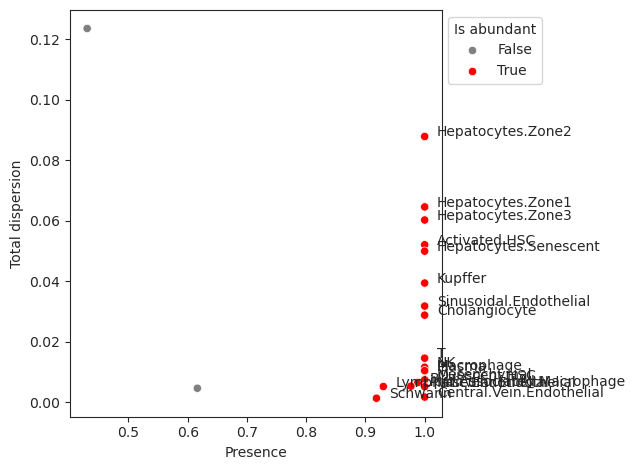

In [70]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

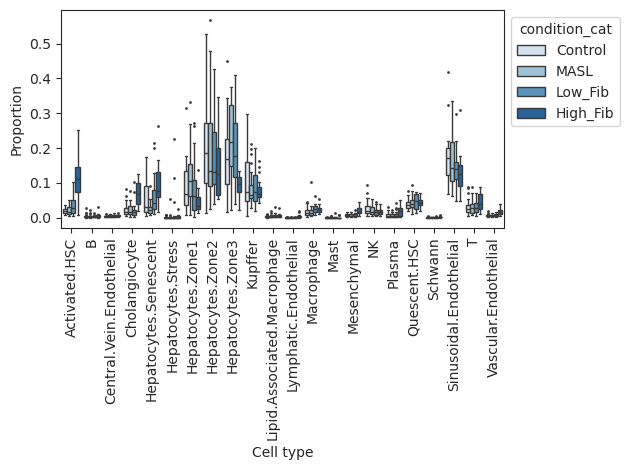

In [71]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [72]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:59<00:00, 166.98it/s]


MCMC sampling finished. (151.737 sec)
Acceptance rate: 80.5%
Compositional Analysis summary:

Data: 86 samples, 22 cell types
Reference index: 1
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
                             Final Parameter  Expected Sample
Cell Type                                                    
Activated.HSC                          0.263       147.301459
B                                     -0.777        52.064390
Central.Vein.Endothelial              -0.595        62.457182
Cholangiocyte                          0.148       131.299533
Hepatocytes.Senescent                  0.614       209.239855
Hepatocytes.Stress                    -1.416        27.480625
Hepatocytes.Zone1                      1.109       343.257614
Hepatocytes.Zone2                      1.920       772.383530
Hepatocytes.Zone3                      1.942       789.564263
Kupffer                                1.333       429.439653
Lipid.Associated.Macrophage           -0.716      

In [73]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_by_fib_pairwise.results')

In [74]:
#all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare(est_fdr=0.1)

(                             Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                              
 Activated.HSC                          0.263   0.083    0.445  0.096   
 B                                     -0.777  -0.977   -0.596  0.101   
 Central.Vein.Endothelial              -0.595  -0.799   -0.370  0.114   
 Cholangiocyte                          0.148  -0.049    0.338  0.100   
 Hepatocytes.Senescent                  0.614   0.413    0.821  0.109   
 Hepatocytes.Stress                    -1.416  -1.626   -1.203  0.115   
 Hepatocytes.Zone1                      1.109   0.919    1.286  0.100   
 Hepatocytes.Zone2                      1.920   1.805    2.041  0.064   
 Hepatocytes.Zone3                      1.942   1.793    2.075  0.075   
 Kupffer                                1.333   1.190    1.467  0.073   
 Lipid.Associated.Macrophage           -0.716  -0.929   -0.518  0.112   
 Lymphatic.Endothelial                 -1.256  -1.4

In [65]:
#intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
#effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.sccoda_effects.csv", sep='\t')

## Hepatocytes

In [75]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [76]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [77]:
meta_df["condition_fib"] = np.select(
    [
        meta_df["condition"] == "Control",
        meta_df["condition"] == "MASL",
        meta_df["Fibrosis.stage"] <= 2,
    ],
    [
        "Control",
        "MASL",
        "Low_Fib",
    ],
    default="High_Fib"
)

In [78]:
meta_df["condition_cat"] = meta_df["condition_fib"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control", "MASL", "Low_Fib", "High_Fib"]
)

meta_df["condition_cat"]

0        MASL
1        MASL
2     Low_Fib
3        MASL
4     Low_Fib
       ...   
81    Low_Fib
82    Low_Fib
83    Control
84       MASL
85    Low_Fib
Name: condition_cat, Length: 86, dtype: category
Categories (4, object): ['Control', 'MASL', 'Low_Fib', 'High_Fib']

In [79]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib',
       'condition_cat'],
      dtype='object')

In [80]:
meta_counts = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/cellsubtypes_donor_cell_nums.tsv', delimiter='\t')
meta_counts

,donor,Activated.HSC,B,Central.Vein.Endothelial,Cholangiocyte,Hepatocytes.Senescent,Hepatocytes.Stress,Hepatocytes.Zone1,Hepatocytes.Zone2,Hepatocytes.Zone3,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,124,29,28,47,392,1,541,5047,2779,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,107,9,15,34,25,0,124,1655,513,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,122,31,33,31,70,0,48,304,119,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,81,3,15,59,124,4,345,3164,784,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,45,12,23,68,263,2002,242,858,3621,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,58,20,19,27,278,0,616,1354,1247,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,140,19,30,26,23,0,7,193,88,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,110,6,26,91,489,0,610,309,1217,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,55,32,32,63,154,0,1812,1658,3050,...,69,5,22,102,24,307,4,999,152,39


In [81]:
(meta_df['donor_demux'] == meta_counts['donor']).sum()

np.int64(86)

In [82]:
combined_df = pd.concat([meta_df, meta_counts.drop(columns=['donor'])], axis=1)
combined_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Macrophage,Mast,Mesenchymal,NK,Plasma,Quescent.HSC,Schwann,Sinusoidal.Endothelial,T,Vascular.Endothelial
0,HL150001,85,47,746,8760,308,4,726,167,8,...,70,4,45,167,56,139,8,694,79,22
1,HL150009,19,34,459,2317,329,0,227,23,6,...,42,0,52,23,10,170,6,406,36,32
2,HL150013,93,31,553,541,308,31,459,100,1,...,81,31,27,100,62,159,1,493,114,24
3,HL150015,59,59,410,4421,312,1,199,63,7,...,35,1,29,63,56,202,7,379,37,14
4,HL160017,54,68,662,6986,199,0,683,39,2,...,163,0,15,39,42,139,2,604,129,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,171,0,17,55,130,145,4,655,138,18
82,HL230302,115,26,718,311,274,0,533,85,3,...,72,0,32,85,96,102,3,663,157,23
83,HL230316,55,91,821,2625,321,0,287,53,4,...,89,0,20,53,49,191,4,759,110,31
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,69,5,22,102,24,307,4,999,152,39


In [83]:
combined_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib',
       'condition_cat', 'Activated.HSC', 'B', 'Central.Vein.Endothelial',
       'Cholangiocyte', 'Hepatocytes.Senescent', 'Hepatocytes.Stress',
       'Hepatocytes.Zone1', 'Hepatocytes.Zone2', 'Hepatocytes.Zone3',
       'Kupffer', 'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial',
       'Macrophage', 'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC',
       'Schwann', 'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'],
      dtype='object')

In [84]:
combined_df = combined_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [85]:
combined_df = combined_df.drop(columns=['B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'Activated.HSC',
       'B', 'Central.Vein.Endothelial', 'Cholangiocyte', 'Kupffer',
       'Lipid.Associated.Macrophage', 'Lymphatic.Endothelial', 'Macrophage',
       'Mast', 'Mesenchymal', 'NK', 'Plasma', 'Quescent.HSC', 'Schwann',
       'Sinusoidal.Endothelial', 'T', 'Vascular.Endothelial'])
combined_df.columns

Index(['donor_demux', 'batch', 'disease_status', 'condition',
       'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution',
       'Lobular.inflammation', 'Ballooning', 'Portal.inflammation',
       'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI',
       'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat',
       'Hepatocytes.Senescent', 'Hepatocytes.Stress', 'Hepatocytes.Zone1',
       'Hepatocytes.Zone2', 'Hepatocytes.Zone3'],
      dtype='object')

In [86]:
# Manually do what from_pandas does, but correctly
covariate_data = combined_df.loc[:, ['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat']]
covariate_data.index = covariate_data.index.astype(str)

count_cols = [c for c in combined_df.columns if c not in covariate_data.columns]
count_data = combined_df.loc[:, count_cols]
count_data.index = count_data.index.astype(str)

import anndata
data_all = anndata.AnnData(X=count_data, obs=covariate_data)

In [87]:
data_all

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_fib', 'condition_cat'

In [88]:
data_hep = data_all

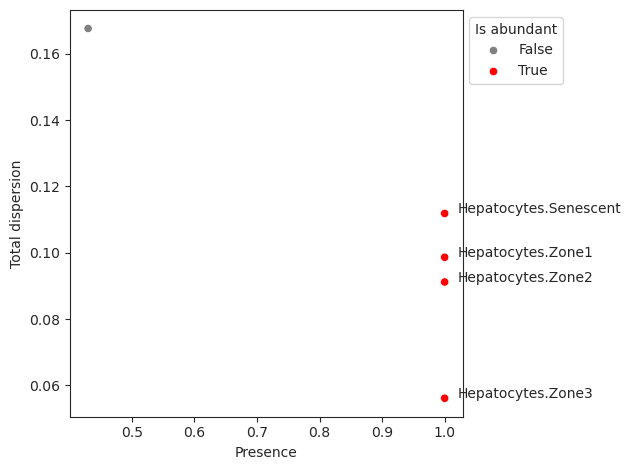

In [89]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

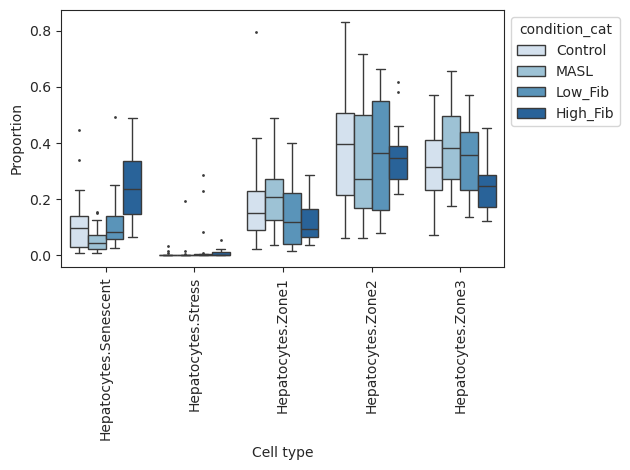

In [90]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [91]:
model_all = mod.CompositionalAnalysis(data_all, formula="C(condition_cat, Treatment('Control'))", reference_cell_type="Hepatocytes.Zone2")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary(est_fdr=0.1)

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:04<00:00, 311.73it/s]


MCMC sampling finished. (82.610 sec)
Acceptance rate: 46.4%
Compositional Analysis summary:

Data: 86 samples, 5 cell types
Reference index: 3
Formula: C(condition_cat, Treatment('Control'))

Intercepts:
                       Final Parameter  Expected Sample
Cell Type                                              
Hepatocytes.Senescent            0.063       306.198451
Hepatocytes.Stress              -1.602        57.929886
Hepatocytes.Zone1                0.472       460.924118
Hepatocytes.Zone2                1.215       968.969781
Hepatocytes.Zone3                1.166       922.634741


Effects:
                                                                          Final Parameter  \
Covariate                                          Cell Type                                
C(condition_cat, Treatment('Control'))[T.MASL]     Hepatocytes.Senescent         0.000000   
                                                   Hepatocytes.Stress            0.000000   
                     

In [92]:
all_results.set_fdr(est_fdr=0.1)
all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_by_fib_pairwise.results')

In [20]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results', "rb") as f:
#    all_results = pkl.load(f)

In [93]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare(est_fdr=0.1)

(                       Final Parameter  HDI 3%  HDI 97%     SD  \
 Cell Type                                                        
 Hepatocytes.Senescent            0.063  -0.174    0.304  0.127   
 Hepatocytes.Stress              -1.602  -1.832   -1.354  0.134   
 Hepatocytes.Zone1                0.472   0.257    0.693  0.115   
 Hepatocytes.Zone2                1.215   1.050    1.403  0.094   
 Hepatocytes.Zone3                1.166   0.972    1.368  0.106   
 
                        Expected Sample  
 Cell Type                               
 Hepatocytes.Senescent       306.198451  
 Hepatocytes.Stress           57.929886  
 Hepatocytes.Zone1           460.924118  
 Hepatocytes.Zone2           968.969781  
 Hepatocytes.Zone3           922.634741  ,
                                                                           Final Parameter  \
 Covariate                                          Cell Type                                
 C(condition_cat, Treatment('Control'))[T.MASL

# Write out results

In [94]:
# Fibrosis - Ct
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.sccoda_effects.csv", sep='\t')

In [95]:
# Fibrosis - Cellsub
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_cell_subtype.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_cell_subtype.sccoda_effects.csv", sep='\t')

In [96]:
# Fibrosis - Hep
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage_Hep_subtype.sccoda_effects.csv", sep='\t')

In [97]:
# Control v condition - Ct
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_distinct.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_distinct.sccoda_effects.csv", sep='\t')

In [98]:
# Control v condition - Cellsub
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_distinct.sccoda_effects.csv", sep='\t')

In [99]:
# Control v condition - Hep
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_distinct.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_distinct.sccoda_effects.csv", sep='\t')

In [100]:
# Control v condition - Fib
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_by_fib_pairwise.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_by_fib_pairwise.sccoda_effects.csv", sep='\t')

In [104]:
# Control v condition - Fib
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_by_fib_pairwise.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_cell_subtype_by_fib_pairwise.sccoda_effects.csv", sep='\t')

In [102]:
# Control v condition - Fib
with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_by_fib_pairwise.results', "rb") as f:
    all_results = pkl.load(f)
    
intercept_df, effect_df = all_results.summary_prepare(est_fdr=0.1)
effect_df.to_csv("/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_Hep_subtype_by_fib_pairwise.sccoda_effects.csv", sep='\t')

In [114]:
data_hep

AnnData object with n_obs × n_vars = 86 × 5
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [115]:
data_ct

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [116]:
data_sub

AnnData object with n_obs × n_vars = 86 × 22
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

In [152]:
viz.boxplots(data_ct, 'Fibrosis_stage', y_scale='relative')
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Celltypes_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [158]:
viz.boxplots(data_sub, 'Fibrosis_stage', y_scale='relative')
plt.gcf().set_size_inches(12, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Subtypes_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [154]:
viz.boxplots(data_hep, 'Fibrosis_stage', y_scale='relative')
plt.gcf().set_size_inches(3, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Hep_Fibrosis_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [155]:
viz.boxplots(data_ct, 'condition_cat', y_scale='relative')
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Celltypes_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [156]:
viz.boxplots(data_sub, 'condition_cat', y_scale='relative')
plt.gcf().set_size_inches(12, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Subtypes_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [157]:
viz.boxplots(data_hep, 'condition_cat', y_scale='relative')
plt.gcf().set_size_inches(3, 4.8)
plt.savefig('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/scCODA/260528_scCODA_Hep_Condition_Built_In_Boxplot.pdf', bbox_inches='tight', transparent=True)
plt.close()

In [166]:
sns.color_palette(palette='Oranges')

[(0.9955709342560554, 0.8907958477508651, 0.7855132641291811),
 (0.9921568627450981, 0.7769934640522875, 0.5727028066128412),
 (0.9921568627450981, 0.6280507497116494, 0.34226835832372166),
 (0.9648442906574395, 0.47100346020761247, 0.14197616301422528),
 (0.8782929642445213, 0.31990772779700116, 0.024405997693194924),
 (0.6768627450980392, 0.22089965397923875, 0.010749711649365626)]

In [9]:
import importlib
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt

from sccoda.util import comp_ana as mod
from sccoda.util import cell_composition_data as dat
from sccoda.util import data_visualization as viz

import sccoda.datasets as scd

In [10]:
meta_df = pd.read_csv('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/01_DESEQ_RNA/RNA.meta.tsv', delimiter='\t')
meta_df

,donor_demux,B,Cholangiocyte,Endothelial,Hepatocytes,HSC,Mast,Myeloid,NK,Schwann,...,Lobular.inflammation,Ballooning,Portal.inflammation,Hepatocyte.necrosis,MASH.CRN.score..X.8,Gender,Age,BMI,BMI.scaled,Age.scaled
0,HL150001,85,47,746,8760,308,4,726,167,8,...,0,0.0,0,0,1,M,47,27.1,-0.638585,-0.015536
1,HL150009,19,34,459,2317,329,0,227,23,6,...,0,0.0,0,0,1,M,37,29.4,-0.334687,-0.757788
2,HL150013,93,31,553,541,308,31,459,100,1,...,1,1.0,1-2 Mild/moderate,Spotty,3,M,45,35.0,0.405238,-0.163986
3,HL150015,59,59,410,4421,312,1,199,63,7,...,0,0.0,1,0,3,M,59,29.1,-0.374326,0.875167
4,HL160017,54,68,662,6986,199,0,683,39,2,...,1,0.0,2,0,2,M,31,24.0,-1.048186,-1.203139
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,HL230212,150,27,695,3495,220,0,724,55,4,...,1,0.0,2,0,3,M,56,32.2,0.035275,0.652491
82,HL230302,115,26,718,311,274,0,533,85,3,...,0,1.0,0,NaN,1,F,60,28.5,-0.453603,0.949392
83,HL230316,55,91,821,2625,321,0,287,53,4,...,0,NaN,1,minimal centrizonal,0,F,58,29.3,-0.347900,0.800942
84,HL230324,56,63,1071,6674,384,5,623,102,4,...,2,0.0,1,NaN,3,M,60,34.2,0.299534,0.949392


In [11]:
meta_df['condition']

0        MASL
1        MASL
2        MASH
3        MASL
4      MetALD
       ...   
81       MASH
82       MASH
83    Control
84       MASL
85     MetALD
Name: condition, Length: 86, dtype: object

In [12]:
meta_df["condition_cat"] = meta_df["condition"].astype("category")
meta_df["condition_cat"] = meta_df["condition_cat"].cat.set_categories(
    ["Control","MASL","MASH","MetALD"]
)
meta_df["condition_num"] = meta_df["condition_cat"].cat.codes


meta_df["condition_num"]

0     1
1     1
2     2
3     1
4     3
     ..
81    2
82    2
83    0
84    1
85    3
Name: condition_num, Length: 86, dtype: int8

In [13]:
meta_df.columns

Index(['donor_demux', 'B', 'Cholangiocyte', 'Endothelial', 'Hepatocytes',
       'HSC', 'Mast', 'Myeloid', 'NK', 'Schwann', 'T', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis.stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat',
       'condition_num'],
      dtype='object')

In [14]:
meta_df = meta_df.rename(columns={"Fibrosis.stage": "Fibrosis_stage"})

In [15]:
data_all = dat.from_pandas(meta_df, covariate_columns=['donor_demux', 'batch',
       'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage',
       'Fat.distribution', 'Lobular.inflammation', 'Ballooning',
       'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8',
       'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat','condition_num'])
data_all

AnnData object with n_obs × n_vars = 86 × 10
    obs: 'donor_demux', 'batch', 'disease_status', 'condition', 'Steatosis.grade', 'Fibrosis_stage', 'Fat.distribution', 'Lobular.inflammation', 'Ballooning', 'Portal.inflammation', 'Hepatocyte.necrosis', 'MASH.CRN.score..X.8', 'Gender', 'Age', 'BMI', 'BMI.scaled', 'Age.scaled', 'condition_cat', 'condition_num'

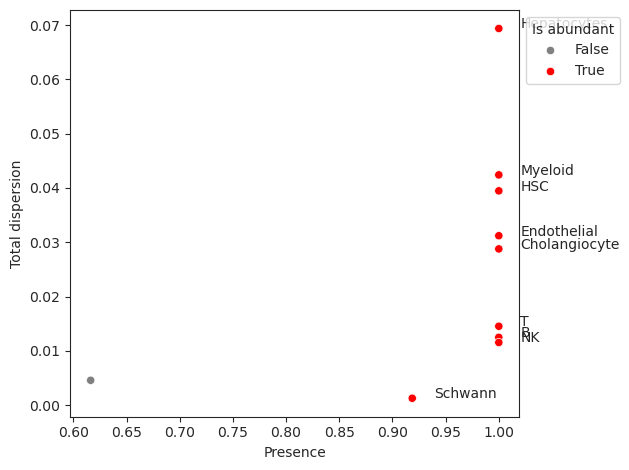

In [16]:
viz.rel_abundance_dispersion_plot(
    data=data_all,
    abundant_threshold=0.9
)
plt.show()

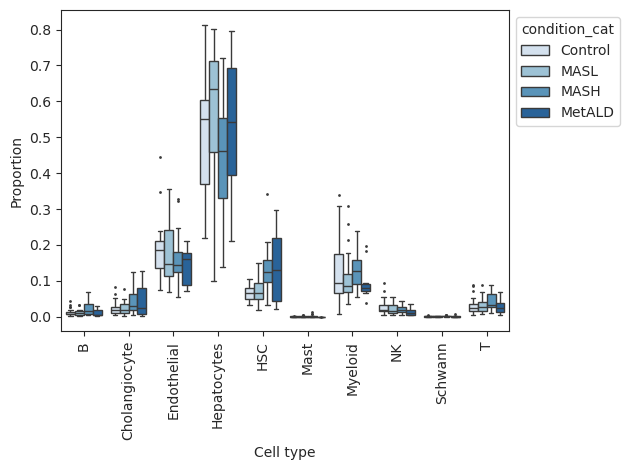

In [17]:
az = viz.boxplots(data_all, 'condition_cat', y_scale='relative')

In [18]:
data_ct = data_all

In [29]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="Endothelial")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:14<00:00, 269.80it/s]


MCMC sampling finished. (94.334 sec)
Acceptance rate: 19.3%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 2
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.516        99.864470
Cholangiocyte           -0.667        85.868235
Endothelial              1.625       849.641051
Hepatocytes              2.807      2770.585553
HSC                     -2.163        19.236586
Mast                    -1.363        42.811809
Myeloid                  1.109       507.153626
NK                      -0.047       159.622870
Schwann                 -2.880         9.391584
T                        0.190       202.312588


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     1.911651     1.786306e-19   
              Cholangiocyte        -3.

In [30]:
model_all = mod.CompositionalAnalysis(data_all, formula="condition_num", reference_cell_type="B")
all_results = model_all.sample_hmc()
all_results.set_fdr(est_fdr=0.1)
all_results.summary()

Zero counts encountered in data! Added a pseudocount of 0.5.


100%|██████████| 20000/20000 [01:13<00:00, 273.12it/s]


MCMC sampling finished. (92.549 sec)
Acceptance rate: 58.0%
Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 0
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.333       106.104754
Cholangiocyte            0.011       149.669099
Endothelial              1.722       828.342609
Hepatocytes              2.756      2329.541738
HSC                      0.941       379.337704
Mast                    -1.481        33.663927
Myeloid                  1.293       539.383515
NK                       0.008       149.220764
Schwann                 -1.253        42.284765
T                        0.244       188.939498


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                          0.0       106.104754   
              Cholangiocyte           

In [25]:
all_results.set_fdr(est_fdr=0.1)
#all_results.save('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_condition_num.results')

In [26]:
#with open('/tscc/projects/ps-gaultonlab/welison/FNIH.Liver/04_Celltype_Proportions/260330_scCODA_Fibrosis_stage.results', "rb") as f:
#    all_results = pkl.load(f)

In [27]:
all_results.summary()

Compositional Analysis summary:

Data: 86 samples, 10 cell types
Reference index: 9
Formula: condition_num

Intercepts:
               Final Parameter  Expected Sample
Cell Type                                      
B                       -0.212       120.030821
Cholangiocyte           -0.042       142.273115
Endothelial             -3.115         6.584699
Hepatocytes              3.035      3086.362687
HSC                      0.998       402.521517
Mast                    -1.343        38.735192
Myeloid                  1.389       595.111363
NK                      -0.087       136.012739
Schwann                 -2.157        17.162874
T                        0.307       201.693366


Effects:
                             Final Parameter  Expected Sample  \
Covariate     Cell Type                                         
condition_num B                     0.000000     6.381741e-55   
              Cholangiocyte        -1.844803     1.195588e-55   
              Endothelial        

In [31]:
all_results.set_fdr(est_fdr=0.1)
all_results.summary_prepare()

(               Final Parameter  HDI 3%  HDI 97%     SD  Expected Sample
 Cell Type                                                              
 B                       -0.333  -0.531   -0.154  0.106       106.104754
 Cholangiocyte            0.011  -0.243    0.232  0.129       149.669099
 Endothelial              1.722   1.540    1.907  0.102       828.342609
 Hepatocytes              2.756   2.609    2.920  0.085      2329.541738
 HSC                      0.941   0.705    1.156  0.124       379.337704
 Mast                    -1.481  -1.699   -1.250  0.118        33.663927
 Myeloid                  1.293   1.138    1.447  0.084       539.383515
 NK                       0.008  -0.211    0.227  0.115       149.220764
 Schwann                 -1.253  -1.474   -1.026  0.123        42.284765
 T                        0.244   0.069    0.433  0.098       188.939498,
                              Final Parameter  HDI 3%  HDI 97%     SD  \
 Covariate     Cell Type                          